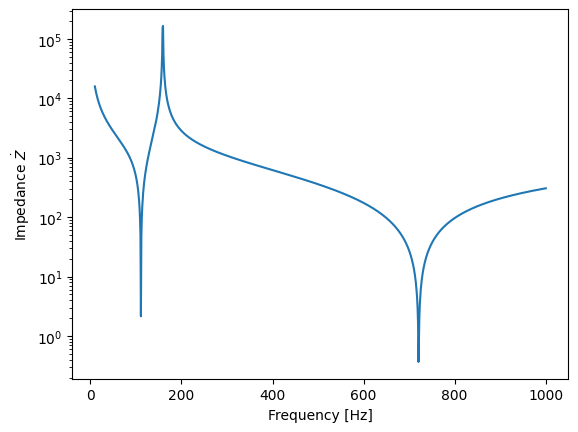

In [8]:
import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from pprint import pprint

from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
import matplotlib.pyplot as plt
import numpy as np
circuit = Circuit('test')
circuit.raw_spice = u'''VIN 1 0 DC 0 AC 10 0
L1 1 2 0.1
C1 2 3 1u
L2 3 0 1
C2 3 0 1u'''
simulator = circuit.simulator(temperature=25, nominal_temperature=25)
res = simulator.ac(start_frequency=10,stop_frequency=1000,number_of_points=1000, variation='lin')
axe = plt.subplot()
v1 = np.array(res.nodes['1'])
i1 = np.array(res.branches['vin'])
plt.semilogy(np.array(res.frequency), np.abs(v1)/np.abs(i1))
axe.set_xlabel('Frequency [Hz]');
axe.set_ylabel(r'Impedance $\dot{Z}$');
plt.savefig('C13reso.png')

In [18]:
res.frequency[151]

FrequencyValue(159.6396396396396 Hz)

In [19]:
np.argmax(np.abs(v1)/np.abs(i1))

151

In [20]:
from sympy import I,solve,symbols,expand_complex,pi,sqrt
w = symbols('omega',real=True)
Z = I*w*0.1 + 1/(I*w*1e-6) + 1/(I*w*1e-6 + 1/(I*w*1))
res = solve(Z,w)
display((res[2]/(2*pi)).evalf())
display((res[3]/(2*pi)).evalf())
(1/(2*pi*sqrt(1*1e-6))).evalf()

111.124780775336

720.824179131019

159.154943091895